# Wake Iter 感度確認

`G103A.vsp3` に対して VSPAERO の `STABILITY_DEFAULT` を実行し、`WakeNumIter` を変えたときの安定微係数の感度を見る notebook です。

今回の方針では、各 wake iter ごとに新しい case ディレクトリを作り、その中へ `G103A.vsp3` をコピーしてから、そのコピーを読み込んで VSPAERO を実行します。

処理の流れは以下の通りです。

1. `G103A.vsp3` の場所を確認する
2. `wake_iter = 4 + Fibonacci` を 40 程度まで作る
3. `validate_vsp3_for_stability_derivatives()` で元モデルの前提を確認する
4. wake iter ごとに case ディレクトリを作る
5. case ディレクトリに `G103A.vsp3` をコピーする
6. case ディレクトリ内で `vsp_stability_derivatives()` を実行する
7. 出力された `.stab` を `read_vspaero_stab()` で読み直す
8. wake iter と安定微係数の対応表を CSV に保存する
9. wake iter を横軸、安定微係数を縦軸としてプロットする

この notebook は OpenVSP Python API が使える環境で手動実行する感度確認用です。CI で毎回走らせる軽量テストではありません。


## 1. import とリポジトリ位置の解決

`examples/notebooks` から実行しても、リポジトリ直下や他の作業ディレクトリから実行しても動くように、親ディレクトリを上にたどって `src/AnalysisVSPAERO.py` を探します。


In [19]:
from __future__ import annotations

from pathlib import Path
import math
import shutil
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Find repository root by looking for src/AnalysisVSPAERO.py.
start_dir = Path.cwd().resolve()
repo_root = None
for candidate in [start_dir, *start_dir.parents]:
    if (candidate / "src" / "AnalysisVSPAERO.py").exists():
        repo_root = candidate
        break

if repo_root is None:
    raise FileNotFoundError(
        "Could not find repository root. Run this notebook inside the OpenVSP repository "
        "or set repo_root manually."
    )

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.AnalysisVSPAERO import (  # noqa: E402
    validate_vsp3_for_stability_derivatives,
    vsp_stability_derivatives,
)
from src.TrimTurnSolver import read_vspaero_stab  # noqa: E402
from src.util import workdir  # noqa: E402

print("repo_root:", repo_root)


repo_root: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP


## 2. 入力ファイルと解析条件

`G103A.vsp3` は、提示されたディレクトリ構成に合わせて `examples/models/G103A/G103A.vsp3` を既定値にします。

各 case ディレクトリには `G103A.vsp3` をコピーしてから解析します。これにより、各 wake iter の入力 `.vsp3` と出力 `.vspaero` / `.stab` が同じディレクトリに揃います。


In [20]:
vsp3_path = repo_root / "examples" / "models" / "G103A" / "G103A.vsp3"
output_dir = repo_root / "examples" / "notebooks" / "wake_iter_sensitivity"
output_dir.mkdir(parents=True, exist_ok=True)

alpha_deg = 2.0
mach = 0.1
reynolds = 4.4e6
ncpu = 8

# Keep solver stdout suppressed by default. Use "stdout" if you want to see VSPAERO solver output.
redirect_file = ""
verbose = 1
vspaero_verbose = 0

print("vsp3_path:", vsp3_path)
print("output_dir:", output_dir)

if not vsp3_path.exists():
    raise FileNotFoundError(vsp3_path)


vsp3_path: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\models\G103A\G103A.vsp3
output_dir: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\wake_iter_sensitivity


## 3. wake iter 配列

指定通り、`4 + Fibonacci` を基本にして 40 付近まで試します。最後に `40` も明示的に加えます。


In [21]:
def wake_iters_from_four_plus_fibonacci(limit: int = 40, include_limit: bool = True) -> list[int]:
    fib = [1, 2]
    while 4 + fib[-1] < limit:
        fib.append(fib[-1] + fib[-2])
    values = {4 + value for value in fib if 4 + value <= limit}
    if include_limit:
        values.add(int(limit))
    return sorted(values)

wake_iters = wake_iters_from_four_plus_fibonacci(40, include_limit=True)
wake_iters = [3,4,8,10,11,13,14,15,16,18,19,20]


## 4. 元モデルの事前検証

モデルのGeom名、Set名、Control Surface Group、VSPAERO設定を先に確認します。コピー後の `.vsp3` はこの元ファイルと同一なので、通常はこの検証を1回行えば十分です。


In [22]:
validation = validate_vsp3_for_stability_derivatives(vsp3_path, verbose=2)
print("passed:", validation["passed"])
print("errors:", validation["errors"])
print("warnings:", validation["warnings"])

if not validation["passed"]:
    raise RuntimeError(validation["errors"])



-> Validate G103A stability-derivative preflight: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\models\G103A\G103A.vsp3
 Checking required Geoms...
 Checking required control-surface Subsurfaces...
 Checking ThickGeom / ThinGeom sets...
 Checking VSPAERO settings...
 Checking VSPAERO control-surface groups and gains...
 Validation PASSED: 0 error(s), 0 warning(s)
passed: True
errors: []
warnings: []


## 5. case ディレクトリ操作の補助処理

VSPAEROの出力が混ざらないように、各 wake iter ごとにディレクトリを分けます。再実行時に古い `.stab` を拾わないよう、既存のVSPAERO出力は削除し、`G103A.vsp3` は毎回コピーし直します。


In [23]:
def clean_case_outputs(case_dir: Path, case_stem: str) -> None:
    for path in case_dir.glob(f"{case_stem}*"):
        if not path.is_file():
            continue
        if path.suffix.lower() == ".vsp3":
            continue
        path.unlink()


def prepare_case_vsp3(case_dir: Path, source_vsp3_path: Path) -> Path:
    case_dir.mkdir(parents=True, exist_ok=True)
    case_vsp3_path = case_dir / source_vsp3_path.name
    clean_case_outputs(case_dir, case_vsp3_path.stem)
    shutil.copy2(source_vsp3_path, case_vsp3_path)
    return case_vsp3_path


def find_stab_file(case_dir: Path, preferred_stem: str) -> Path | None:
    preferred = case_dir / f"{preferred_stem}.stab"
    if preferred.exists():
        return preferred
    candidates = sorted(case_dir.glob("*.stab"), key=lambda path: path.stat().st_mtime, reverse=True)
    return candidates[0] if candidates else None


def flatten_stab_derivatives(stab, coef_names, derivative_columns) -> dict[str, float]:
    row = {
        "Sref": float(stab.Sref),
        "Cref": float(stab.Cref),
        "Bref": float(stab.Bref),
        "Vinf": float(stab.V0),
        "rho": math.nan if stab.rho0 is None else float(stab.rho0),
        "AoA_deg": stab.base_condition.get("AoA"),
        "Beta_deg": stab.base_condition.get("Beta"),
        "control_groups": repr(stab.control_groups),
    }
    for coef_name in coef_names:
        if coef_name not in stab.derivatives.index:
            continue
        for derivative_name in derivative_columns:
            if derivative_name in stab.derivatives.columns:
                row[f"{coef_name}_{derivative_name}"] = float(stab.derivatives.loc[coef_name, derivative_name])
    return row


## 6. 1ケースだけ試す

最初に最小の wake iter だけ実行して、OpenVSP環境、パス、出力ファイルの状態を確認します。


In [24]:
first_wake_iter = wake_iters[0]
first_case_dir = output_dir / f"wake_iter_{first_wake_iter:03d}"
first_case_vsp3_path = prepare_case_vsp3(first_case_dir, vsp3_path)

with workdir(first_case_dir):
    first_report = vsp_stability_derivatives(
        first_case_vsp3_path.name,
        alpha=alpha_deg,
        mach=mach,
        reynolds=reynolds,
        ncpu=ncpu,
        wake_num_iter=first_wake_iter,
        fixed_wake_flag=None,
        redirect_file=redirect_file,
        stop_before_run=False,
        vspaero_verbose=vspaero_verbose,
        verbose=verbose,
    )

print("case_vsp3_path:", first_case_vsp3_path)
print("passed:", first_report["passed"])
print("errors:", first_report["errors"])
print("warnings:", first_report["warnings"])
print("timing:", first_report["timing"])

first_stab_path = find_stab_file(first_case_dir, first_case_vsp3_path.stem)
if first_stab_path is None:
    raise FileNotFoundError(f"No .stab file was written in {first_case_dir}")

first_stab = read_vspaero_stab(first_stab_path)
first_stab.derivatives



-> Calculate G103A VSPAERO stability derivatives: G103A.vsp3
 Executing VSPAEROComputeGeometry...
Executing VSPAEROSweep with STABILITY_DEFAULT
 Stability derivative calculation PASSED: 0 error(s), 0 warning(s)
case_vsp3_path: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\wake_iter_sensitivity\wake_iter_003\G103A.vsp3
passed: True
errors: []
warnings: []
timing: {'read_vsp3_elapsed_s': 0.16810270003043115, 'compute_geometry_elapsed_s': 0.2074307999573648, 'compute_geometry_analysis_duration_s': 0.207, 'vspaero_sweep_elapsed_s': 120.82126679999055, 'vspaero_sweep_analysis_duration_s': 120.821, 'result_extraction_elapsed_s': 0.0010765999904833734, 'total_elapsed_s': 121.20022460003383}


,Base,Alpha,Beta,p,q,r,Mach,U,ConGrp_1,ConGrp_2,ConGrp_3
Coef,,,,,,,,,,,
CFx,-0.003684,-0.543463,0.040872,0.006895,-0.856673,0.007195,-0.000544,-0.000054,0.003699,-0.000736,0.003085
CFy,0.000223,-0.285945,-0.483797,-0.195416,-0.307615,0.148100,-0.000311,-0.000031,-0.083704,-0.027476,0.120762
CFz,0.534980,3.787017,-2.042843,-0.112125,11.256151,0.002093,0.068718,0.006872,-0.182381,0.147467,-0.154687
CMx,-0.000247,-0.174844,-0.115997,0.659495,0.088210,-0.123371,-0.000228,-0.000023,0.357054,-0.016325,-0.023920
CMy,-0.059108,0.625095,2.302599,0.180002,-20.259164,0.143511,0.001102,0.000110,0.280420,-1.229286,0.186857
CMz,0.000009,-0.076943,-0.108121,0.062071,-0.068961,0.035733,-0.000121,-0.000012,-0.009868,-0.007735,0.032855
CL,0.534783,3.788713,-2.043025,-0.112297,11.279191,0.001841,0.068695,0.006869,-0.182399,0.147403,-0.154700
CD,0.014989,0.124478,-0.030588,0.002978,-0.463317,0.007264,0.001855,0.000186,-0.002668,0.004411,-0.002315
CS,0.000223,-0.285945,-0.468813,-0.195416,-0.307615,0.148100,-0.000311,-0.000031,-0.083704,-0.027476,0.120762


## 7. wake iter sweep

全 wake iter を回します。各 case ディレクトリには `G103A.vsp3` をコピーしてから実行します。


In [25]:
rows = []
coef_names = ["CL", "CD", "CS", "CMl", "CMm", "CMn"]
derivative_columns = ["Base", "Alpha", "Beta", "p", "q", "r", "Mach", "U", "ConGrp_1", "ConGrp_2", "ConGrp_3"]

sweep_start = time.perf_counter()

for case_index, wake_iter in enumerate(wake_iters, start=1):
    case_dir = output_dir / f"wake_iter_{wake_iter:03d}"
    case_vsp3_path = prepare_case_vsp3(case_dir, vsp3_path)

    print(f"[{case_index}/{len(wake_iters)}] WakeNumIter = {wake_iter}", flush=True)
    case_start = time.perf_counter()

    with workdir(case_dir):
        report = vsp_stability_derivatives(
            case_vsp3_path.name,
            alpha=alpha_deg,
            mach=mach,
            reynolds=reynolds,
            ncpu=ncpu,
            wake_num_iter=wake_iter,
            fixed_wake_flag=None,
            redirect_file=redirect_file,
            stop_before_run=False,
            vspaero_verbose=vspaero_verbose,
            verbose=verbose,
        )

    row = {
        "wake_iter": int(wake_iter),
        "passed": bool(report["passed"]),
        "case_dir": str(case_dir),
        "vsp3_path": str(case_vsp3_path),
        "errors": repr(report["errors"]),
        "warnings": repr(report["warnings"]),
        "elapsed_s": time.perf_counter() - case_start,
        "total_elapsed_s": report.get("timing", {}).get("total_elapsed_s", math.nan),
        "compute_geometry_elapsed_s": report.get("timing", {}).get("compute_geometry_elapsed_s", math.nan),
        "vspaero_sweep_elapsed_s": report.get("timing", {}).get("vspaero_sweep_elapsed_s", math.nan),
        "result_extraction_elapsed_s": report.get("timing", {}).get("result_extraction_elapsed_s", math.nan),
    }

    stab_path = find_stab_file(case_dir, case_vsp3_path.stem)
    row["stab_path"] = "" if stab_path is None else str(stab_path)
    if row["passed"] and stab_path is not None:
        stab = read_vspaero_stab(stab_path)
        row.update(flatten_stab_derivatives(stab, coef_names, derivative_columns))

    rows.append(row)
    print(f"    passed={row['passed']}, elapsed={row['elapsed_s']:.1f} s, stab={row['stab_path']}", flush=True)

results = pd.DataFrame(rows).sort_values("wake_iter").reset_index(drop=True)
results_path = output_dir / "wake_iter_sensitivity.csv"
results.to_csv(results_path, index=False)

print(f"Done. elapsed={time.perf_counter() - sweep_start:.1f} s")
print("results_path:", results_path)
results


[1/12] WakeNumIter = 3

-> Calculate G103A VSPAERO stability derivatives: G103A.vsp3
 Executing VSPAEROComputeGeometry...
Executing VSPAEROSweep with STABILITY_DEFAULT
 Stability derivative calculation PASSED: 0 error(s), 0 warning(s)
    passed=True, elapsed=117.9 s, stab=C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\wake_iter_sensitivity\wake_iter_003\G103A.stab
[2/12] WakeNumIter = 4

-> Calculate G103A VSPAERO stability derivatives: G103A.vsp3
 Executing VSPAEROComputeGeometry...
Executing VSPAEROSweep with STABILITY_DEFAULT
 Stability derivative calculation PASSED: 0 error(s), 0 warning(s)
    passed=True, elapsed=145.2 s, stab=C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\wake_iter_sensitivity\wake_iter_004\G103A.stab
[3/12] WakeNumIter = 8

-> Calculate G103A VSPAERO stability derivatives: G103A.vsp3
 Executing VSPAEROComputeGeometry...
Executing VSPAEROSweep with STABILITY_DEFAULT
 Stability derivative calculation PASSED: 0 error(s), 0 wa

,wake_iter,passed,case_dir,vsp3_path,errors,warnings,elapsed_s,total_elapsed_s,compute_geometry_elapsed_s,vspaero_sweep_elapsed_s,...,CMn_Alpha,CMn_Beta,CMn_p,CMn_q,CMn_r,CMn_Mach,CMn_U,CMn_ConGrp_1,CMn_ConGrp_2,CMn_ConGrp_3
0,3,True,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,[],[],117.876113,117.874616,0.219083,117.461232,...,0.076943,0.108121,-0.062071,0.068961,-0.035733,0.000121,1.210000e-05,0.009868,0.007735,-0.032855
1,4,True,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,[],[],145.174315,145.172893,0.245994,144.735511,...,-0.000360,0.033441,-0.067111,-0.007839,-0.035085,-0.000048,-4.800000e-06,0.001475,-0.000655,-0.038193
2,8,True,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,[],[],271.132287,271.130780,0.236425,270.700605,...,-0.003786,0.027664,-0.067600,-0.001514,-0.035172,-0.000001,-1.000000e-07,0.002066,0.000115,-0.038105
3,10,True,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,[],[],339.858376,339.857267,0.241405,339.429667,...,-0.005930,0.026675,-0.068385,-0.005271,-0.034330,-0.000012,-1.200000e-06,0.001285,-0.000570,-0.038334
4,11,True,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,[],[],368.476226,368.474469,0.243029,368.034328,...,-0.002173,0.031532,-0.068065,-0.003456,-0.036119,-0.000005,-5.000000e-07,0.001665,-0.000231,-0.039530
5,13,True,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,[],[],444.393119,444.391285,0.237887,443.955504,...,0.002041,0.034980,-0.068021,-0.002258,-0.035424,0.000003,3.000000e-07,0.002098,0.000286,-0.038097
6,14,True,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,[],[],475.238968,475.237849,0.261420,474.785132,...,-0.000753,0.032800,-0.068030,-0.074666,-0.034017,-0.000034,-3.400000e-06,0.001924,0.000057,-0.037747
7,15,True,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,[],[],500.153705,500.152009,0.274378,499.669620,...,-0.002504,0.032093,-0.067966,-0.084177,-0.038310,-0.000094,-9.400000e-06,0.001741,-0.000156,-0.039023
8,16,True,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,[],[],536.642469,536.641183,0.267205,536.183825,...,-0.001906,0.033358,-0.067985,-0.060022,-0.039659,-0.000101,-1.010000e-05,0.001824,-0.000122,-0.039672
9,18,True,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,[],[],599.327891,599.326571,0.266241,598.865666,...,0.002442,0.035222,-0.067990,-0.042111,-0.038966,-0.000124,-1.240000e-05,0.002243,0.000236,-0.037706


## 8. 安定微係数のプロット

まずは代表的な安定微係数をプロットします。列名は `.stab` の読み取り結果に依存するため、存在する列だけを描画します。


In [26]:
results = pd.read_csv(f"./wake_iter_sensitivity.copy.csv")

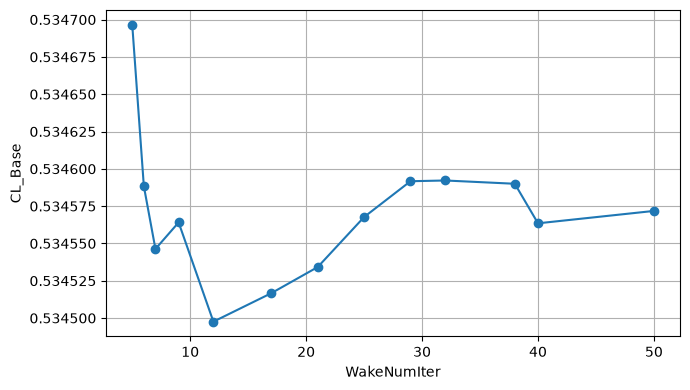

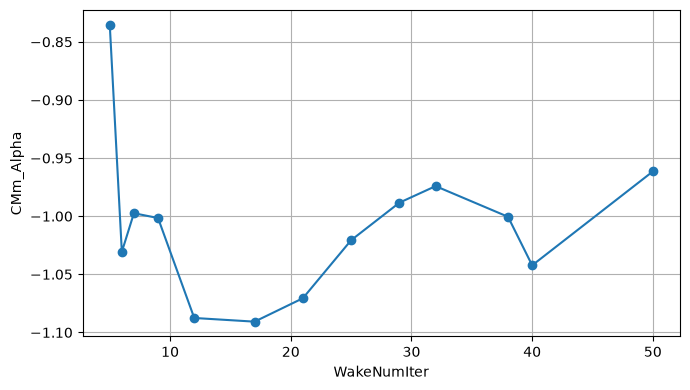

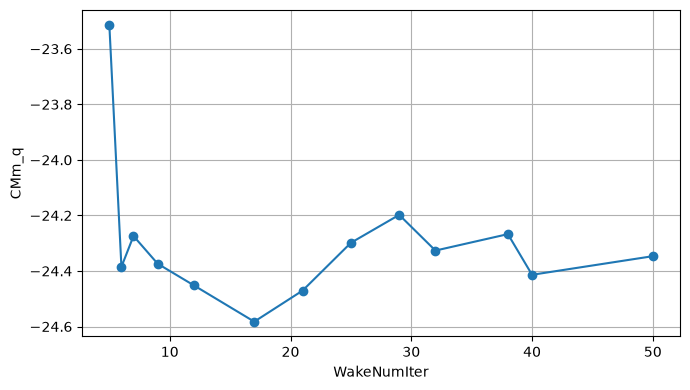

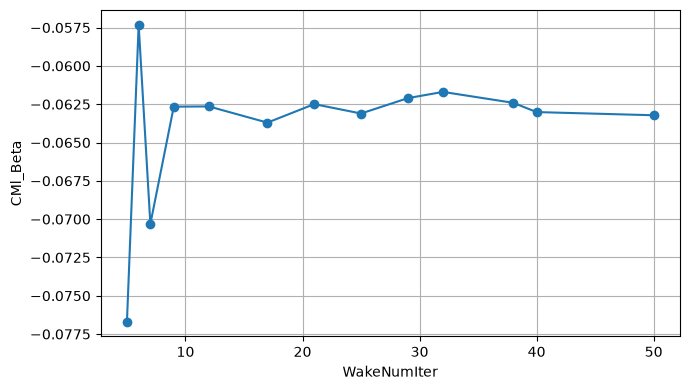

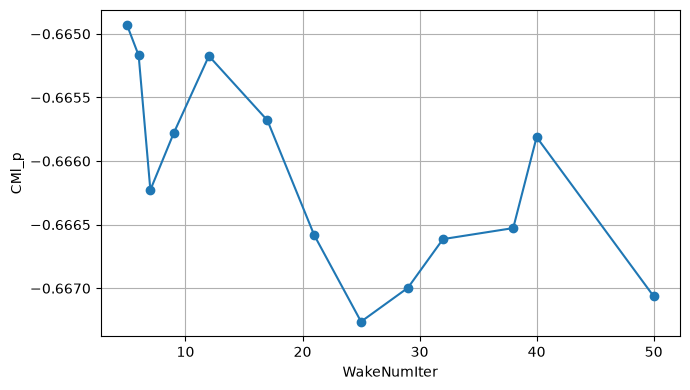

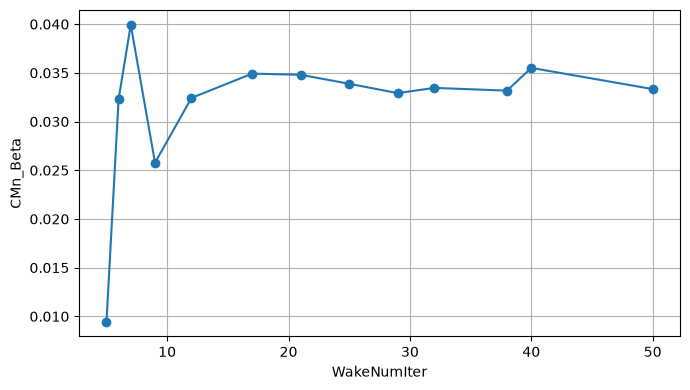

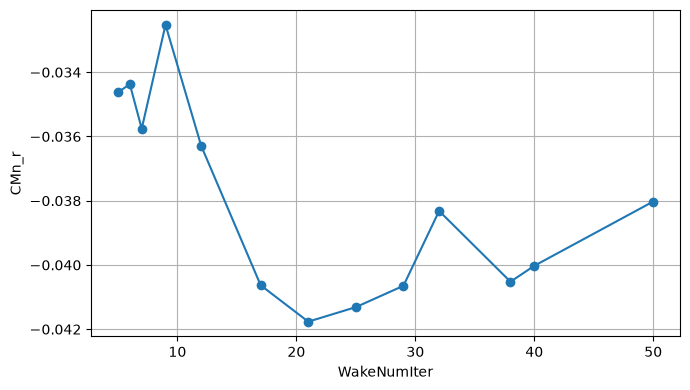

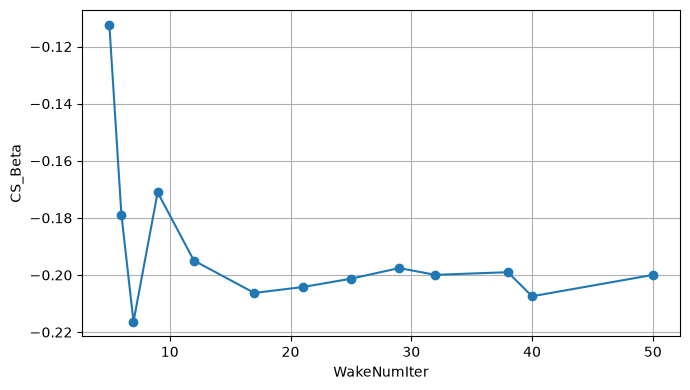

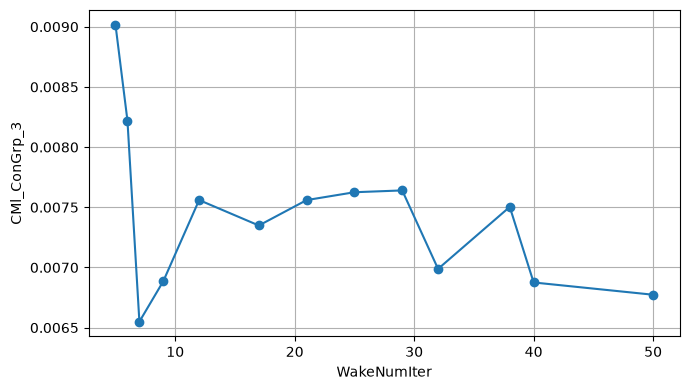

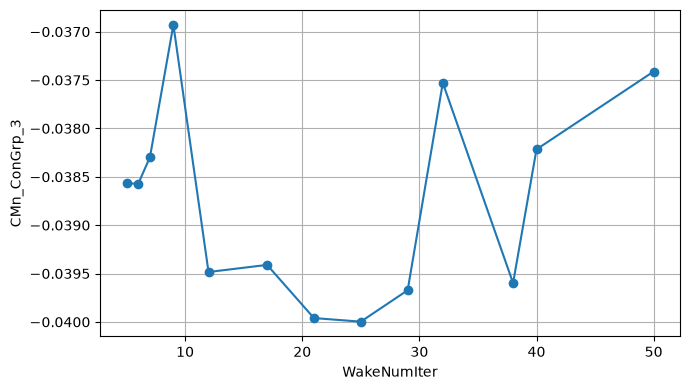

plot_dir: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\wake_iter_sensitivity\plots


In [27]:
plot_columns = [
    "CL_Base",
    "CMm_Alpha",
    "CMm_q",
    "CMl_Beta",
    "CMl_p",
    "CMn_Beta",
    "CMn_r",
    "CS_Beta",
    "CMl_ConGrp_3",
    "CMn_ConGrp_3",
]
plot_columns = [column for column in plot_columns if column in results.columns]
plot_dir = output_dir / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

for column in plot_columns:
    valid = results[["wake_iter", column]].dropna()
    if valid.empty:
        continue
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(valid["wake_iter"], valid[column], marker="o")
    ax.set_xlabel("WakeNumIter")
    ax.set_ylabel(column)
    ax.grid(True)
    fig.tight_layout()
    fig.savefig(plot_dir / f"{column}_vs_wake_iter.png", dpi=150)
    plt.show()

print("plot_dir:", plot_dir)


## 9. 最終wake iterとの差分

最大 wake iter の値を暫定基準として、各 wake iter の差分と相対差を見ます。これは厳密な収束判定ではなく、感度確認用の簡易チェックです。


In [28]:
convergence_rows = []
for column in plot_columns:
    valid = results[["wake_iter", column]].dropna()
    if valid.empty:
        continue
    reference = float(valid[column].iloc[-1])
    for row in valid.itertuples(index=False):
        value = float(getattr(row, column))
        difference = value - reference
        relative_difference = math.nan if abs(reference) < 1e-14 else difference / reference
        convergence_rows.append(
            {
                "coefficient": column,
                "wake_iter": int(row.wake_iter),
                "value": value,
                "reference_wake_iter": int(valid["wake_iter"].iloc[-1]),
                "reference_value": reference,
                "difference_from_reference": difference,
                "relative_difference_from_reference": relative_difference,
            }
        )

convergence = pd.DataFrame(convergence_rows)
convergence_path = output_dir / "wake_iter_convergence_to_last.csv"
convergence.to_csv(convergence_path, index=False)
print("convergence_path:", convergence_path)
convergence


convergence_path: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\wake_iter_sensitivity\wake_iter_convergence_to_last.csv


,coefficient,wake_iter,value,reference_wake_iter,reference_value,difference_from_reference,relative_difference_from_reference
0,CL_Base,5,0.534697,50,0.534572,0.000125,0.000233
1,CL_Base,6,0.534588,50,0.534572,0.000017,0.000031
2,CL_Base,7,0.534546,50,0.534572,-0.000026,-0.000048
3,CL_Base,9,0.534564,50,0.534572,-0.000008,-0.000014
4,CL_Base,12,0.534498,50,0.534572,-0.000074,-0.000139
...,...,...,...,...,...,...,...
125,CMn_ConGrp_3,29,-0.039673,50,-0.037412,-0.002261,0.060436
126,CMn_ConGrp_3,32,-0.037529,50,-0.037412,-0.000117,0.003135
127,CMn_ConGrp_3,38,-0.039598,50,-0.037412,-0.002187,0.058444
128,CMn_ConGrp_3,40,-0.038216,50,-0.037412,-0.000805,0.021507


## 10. 計算時間

wake iter と VSPAERO 実行時間の関係を確認します。


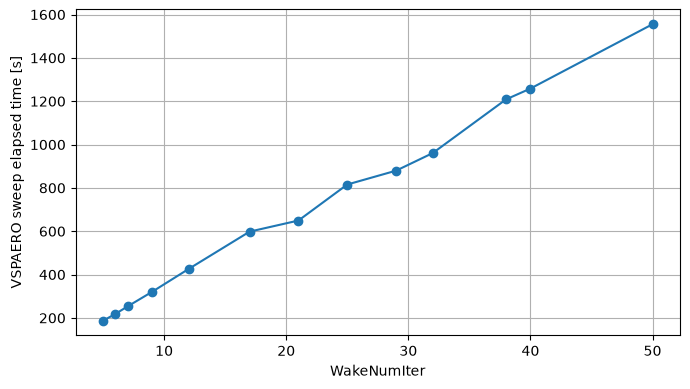

In [29]:
if "vspaero_sweep_elapsed_s" in results.columns:
    valid = results[["wake_iter", "vspaero_sweep_elapsed_s"]].dropna()
    if not valid.empty:
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(valid["wake_iter"], valid["vspaero_sweep_elapsed_s"], marker="o")
        ax.set_xlabel("WakeNumIter")
        ax.set_ylabel("VSPAERO sweep elapsed time [s]")
        ax.grid(True)
        fig.tight_layout()
        fig.savefig(plot_dir / "vspaero_sweep_elapsed_s_vs_wake_iter.png", dpi=150)
        plt.show()


## 11. 出力ファイル確認

各 case ディレクトリに `G103A.vsp3` がコピーされ、その同じディレクトリに `.vspaero` / `.stab` が出力されていることを確認します。


In [30]:
for wake_iter in wake_iters:
    case_dir = output_dir / f"wake_iter_{wake_iter:03d}"
    files = sorted(path.name for path in case_dir.iterdir() if path.is_file())
    print(f"wake_iter_{wake_iter:03d}:")
    for name in files:
        if name.endswith((".vsp3", ".vspaero", ".stab", ".adb", ".cases")):
            print("  ", name)


wake_iter_003:
   G103A.adb
   G103A.adb.cases
   G103A.stab
   G103A.vsp3
   G103A.vspaero
wake_iter_004:
   G103A.adb
   G103A.adb.cases
   G103A.stab
   G103A.vsp3
   G103A.vspaero
wake_iter_008:
   G103A.adb
   G103A.adb.cases
   G103A.stab
   G103A.vsp3
   G103A.vspaero
wake_iter_010:
   G103A.adb
   G103A.adb.cases
   G103A.stab
   G103A.vsp3
   G103A.vspaero
wake_iter_011:
   G103A.adb
   G103A.adb.cases
   G103A.stab
   G103A.vsp3
   G103A.vspaero
wake_iter_013:
   G103A.adb
   G103A.adb.cases
   G103A.stab
   G103A.vsp3
   G103A.vspaero
wake_iter_014:
   G103A.adb
   G103A.adb.cases
   G103A.stab
   G103A.vsp3
   G103A.vspaero
wake_iter_015:
   G103A.adb
   G103A.adb.cases
   G103A.stab
   G103A.vsp3
   G103A.vspaero
wake_iter_016:
   G103A.adb
   G103A.adb.cases
   G103A.stab
   G103A.vsp3
   G103A.vspaero
wake_iter_018:
   G103A.adb
   G103A.adb.cases
   G103A.stab
   G103A.vsp3
   G103A.vspaero
wake_iter_019:
   G103A.adb
   G103A.adb.cases
   G103A.stab
   G103A.vsp3
   G1